# 분류 모델 평가 실습 정답

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)


## 1. 이진 분류 평가 - 유방암 진단

핵심 포인트
- 유방암 데이터는 이진 분류 문제이다.
- `predict()`는 최종 클래스 예측값을 반환한다.
- `predict_proba()`는 각 클래스에 대한 확률을 반환한다.
- ROC Curve와 AUC는 확률값 기반 평가에 사용한다.


In [20]:
# 1) 데이터 로드
breast_cancer = load_breast_cancer()

print('입력 데이터 shape:', breast_cancer.data.shape)
print('타깃 데이터 shape:', breast_cancer.target.shape)
print('타깃 이름:', breast_cancer.target_names)


입력 데이터 shape: (569, 30)
타깃 데이터 shape: (569,)
타깃 이름: ['malignant' 'benign']


In [21]:
# 2) 데이터프레임으로 확인
breast_cancer_df = pd.DataFrame(
    breast_cancer.data,
    columns=breast_cancer.feature_names
)
breast_cancer_df['target'] = breast_cancer.target

breast_cancer_df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [22]:
# 3) train / test 분리
X_train, X_test, y_train, y_test = train_test_split(
    breast_cancer.data,
    breast_cancer.target,
    test_size=0.2,
    random_state=42,
    stratify=breast_cancer.target
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)


X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


In [23]:
# 4) 모델 학습
# max_iter를 충분히 크게 주어 수렴 경고를 줄인다.
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [24]:
# 5) 예측값 / 예측확률 구하기
# predict(): 최종 클래스 예측
# predict_proba()[:, 1]: 양성 클래스(1)일 확률
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print('예측값 일부:', y_pred[:10])
print('양성 확률 일부:', y_pred_proba[:10])


예측값 일부: [0 1 0 1 0 1 1 0 0 0]
양성 확률 일부: [3.41854046e-11 9.99965694e-01 5.02700914e-02 6.03396373e-01
 2.13672683e-09 9.82690576e-01 9.99971024e-01 9.87055830e-06
 4.97322663e-05 1.43015915e-10]


In [25]:
# 6) confusion matrix 확인
cm = confusion_matrix(y_test, y_pred)
print(cm)

cm_df = pd.DataFrame(
    cm,
    index=['Actual 0', 'Actual 1'],
    columns=['Pred 0', 'Pred 1']
)
cm_df


[[39  3]
 [ 1 71]]


,Pred 0,Pred 1
Actual 0,39,3
Actual 1,1,71


In [26]:
# 7) 평가지표 계산
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy :', round(acc, 4))
print('Precision:', round(prec, 4))
print('Recall   :', round(rec, 4))
print('F1-score :', round(f1, 4))


Accuracy : 0.9649
Precision: 0.9595
Recall   : 0.9861
F1-score : 0.9726


In [27]:
# 8) classification report 출력
print(classification_report(y_test, y_pred, target_names=breast_cancer.target_names))


              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



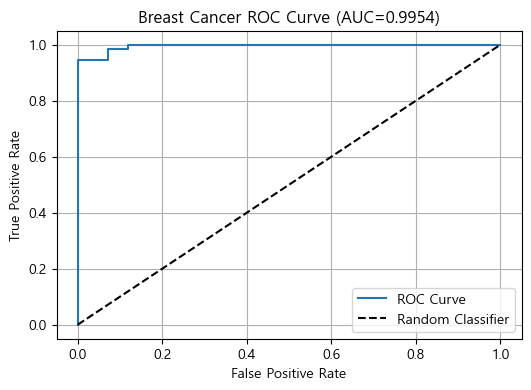

AUC: 0.9954


In [28]:
# 9) ROC Curve 시각화 및 AUC 계산
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Breast Cancer ROC Curve (AUC={auc_score:.4f})')
plt.legend()
plt.grid(True)
plt.show()

print('AUC:', round(auc_score, 4))


## 정리
1. FN은 실제 양성인데 음성으로 잘못 예측한 경우이다.
2. 의료 진단에서는 놓치면 위험하므로 보통 recall을 더 중요하게 보는 경우가 많다.
3. AUC가 1에 가까울수록 다양한 임계치에서 양성과 음성을 잘 구분한다는 뜻이다.

## 2. 다중 분류 평가 - 아이리스

핵심 포인트
- 아이리스는 3개 클래스를 가지는 다중 분류 문제이다.
- 다중 분류에서는 confusion matrix를 통해 어떤 클래스끼리 헷갈리는지 확인하는 것이 중요하다.
- precision, recall, f1-score 계산 시 `average` 옵션이 필요할 수 있다.


In [29]:
# 1) 데이터 로드
iris = load_iris()
X = iris.data
y = iris.target

print('입력 데이터 shape:', X.shape)
print('타깃 데이터 shape:', y.shape)
print('타깃 이름:', iris.target_names)


입력 데이터 shape: (150, 4)
타깃 데이터 shape: (150,)
타깃 이름: ['setosa' 'versicolor' 'virginica']


In [30]:
# 2) train / test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)


X_train shape: (120, 4)
X_test shape: (30, 4)


In [31]:
# 3) 모델 학습
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [32]:
# 4) 예측값 구하기
y_pred = model.predict(X_test)
print('예측값:', y_pred)


예측값: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [33]:
# 5) confusion matrix 출력
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [34]:
# 6) confusion matrix를 DataFrame으로 정리
cm_df = pd.DataFrame(
    cm,
    index=iris.target_names,
    columns=iris.target_names
)
cm_df


,setosa,versicolor,virginica
setosa,10,0,0
versicolor,0,9,1
virginica,0,0,10


In [35]:
# 7) classification report 출력
print(classification_report(y_test, y_pred, target_names=iris.target_names))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [36]:
# 8) macro 평균 기준 평가지표 계산
acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average='macro')
rec_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')

print('Accuracy       :', round(acc, 4))
print('Precision macro:', round(prec_macro, 4))
print('Recall macro   :', round(rec_macro, 4))
print('F1-score macro :', round(f1_macro, 4))


Accuracy       : 0.9667
Precision macro: 0.9697
Recall macro   : 0.9667
F1-score macro : 0.9666


## 정리
1. 다중 분류에서는 어떤 클래스가 다른 클래스와 헷갈리는지 confusion matrix로 확인해야 한다.
2. macro average는 각 클래스를 동일한 비중으로 보고 평균을 내므로 클래스별 성능을 균형 있게 보기 좋다.
3. accuracy만 보면 일부 클래스의 오분류를 놓칠 수 있으므로 classification report를 함께 보는 것이 좋다.